# Anomaly Detection

Anomaly detection (also called **outlier detection**) identifies data points that deviate significantly from expected patterns.

## Types of Anomalies
- **Point anomaly**: A single data point is anomalous (e.g., fraud transaction)
- **Contextual anomaly**: Anomalous in context but not globally (e.g., 30°C in December in Norway)
- **Collective anomaly**: A sequence of points is anomalous together (e.g., intrusion pattern in network traffic)

---

## 1. Statistical Methods

### Z-Score Method
$$z_i = \frac{x_i - \mu}{\sigma}$$
Flag as anomaly if $|z_i| > \tau$ (typically $\tau = 3$).

### IQR Method
$$\text{Lower} = Q_1 - 1.5 \cdot \text{IQR}, \quad \text{Upper} = Q_3 + 1.5 \cdot \text{IQR}$$
where $\text{IQR} = Q_3 - Q_1$.

### Mahalanobis Distance
Accounts for correlations between features:
$$D_M(x) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}$$
Under multivariate normality, $D_M^2 \sim \chi^2_p$ where $p$ = dimensions.

### Grubbs Test
Tests if the most extreme value is an outlier:
$$G = \frac{\max_i |x_i - \bar{x}|}{s}$$

---

## 2. Isolation Forest

Isolates anomalies by random recursive partitioning. Anomalies require fewer splits to isolate.

**Anomaly score** based on average path length $h(x)$:
$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$

where the expected path length normalization:
$$c(n) = 2H(n-1) - \frac{2(n-1)}{n}$$

and $H(i) = \ln(i) + 0.5772$ (Euler-Mascheroni constant).

- $s \approx 1$: definitely anomaly
- $s \approx 0.5$: normal
- $s \ll 0.5$: definitely normal

Method                Precision     Recall         F1
-------------------------------------------------------
Isolation Forest         0.9500     0.9500     0.9500
One-Class SVM            0.8095     0.8500     0.8293
LOF                      0.8500     0.8500     0.8500
Elliptic Envelope        0.9000     0.9000     0.9000


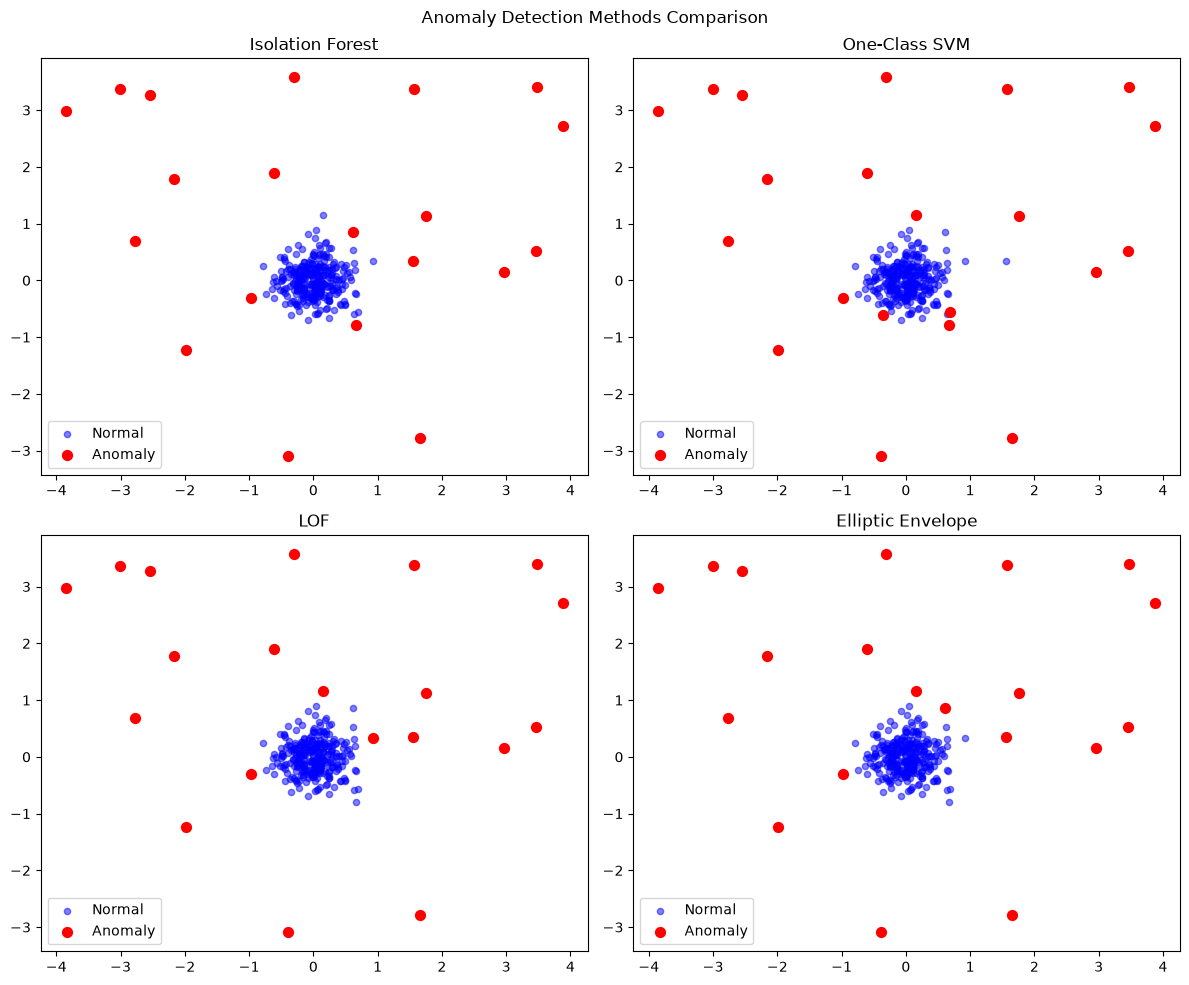

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

# Generate data with anomalies
np.random.seed(42)
n_normal = 300
n_anomaly = 20
X_normal = 0.3 * np.random.randn(n_normal, 2)
X_anomaly = np.random.uniform(-4, 4, (n_anomaly, 2))
X = np.vstack([X_normal, X_anomaly])
y_true = np.concatenate([np.ones(n_normal), -np.ones(n_anomaly)])  # 1=normal, -1=anomaly

# Statistical methods
def zscore_anomaly(X, threshold=3.0):
    z = np.abs((X - X.mean(axis=0)) / X.std(axis=0))
    return (z > threshold).any(axis=1)

def iqr_anomaly(X):
    Q1, Q3 = np.percentile(X, [25, 75], axis=0)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return ((X < lower) | (X > upper)).any(axis=1)

def mahalanobis_anomaly(X, threshold_pct=97.5):
    mu = X.mean(axis=0)
    cov = np.cov(X.T)
    cov_inv = np.linalg.inv(cov)
    diff = X - mu
    dist = np.sqrt(np.sum(diff @ cov_inv * diff, axis=1))
    from scipy import stats
    threshold = np.sqrt(stats.chi2.ppf(threshold_pct/100, df=X.shape[1]))
    return dist > threshold

# ML-based methods
contamination = n_anomaly / len(X)

iso_forest = IsolationForest(contamination=contamination, random_state=42)
y_iso = iso_forest.fit_predict(X)

oc_svm = OneClassSVM(nu=contamination, kernel='rbf', gamma='auto')
y_svm = oc_svm.fit_predict(X)

lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
y_lof = lof.fit_predict(X)

ee = EllipticEnvelope(contamination=contamination, random_state=42)
y_ee = ee.fit_predict(X)

# Evaluation
from sklearn.metrics import f1_score, precision_score, recall_score
methods = {'Isolation Forest': y_iso, 'One-Class SVM': y_svm,
           'LOF': y_lof, 'Elliptic Envelope': y_ee}
print(f"{'Method':<20} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 55)
for name, y_pred in methods.items():
    p = precision_score(y_true, y_pred, pos_label=-1)
    r = recall_score(y_true, y_pred, pos_label=-1)
    f = f1_score(y_true, y_pred, pos_label=-1)
    print(f"{name:<20} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, y_pred) in zip(axes.flat, methods.items()):
    ax.scatter(X[y_pred==1, 0], X[y_pred==1, 1], c='blue', alpha=0.5, s=20, label='Normal')
    ax.scatter(X[y_pred==-1, 0], X[y_pred==-1, 1], c='red', s=50, label='Anomaly')
    ax.set_title(name); ax.legend()
plt.suptitle('Anomaly Detection Methods Comparison'); plt.tight_layout(); plt.show()

---

## 3. Local Outlier Factor (LOF)

Compares local density of a point to its neighbors. Points in low-density regions are outliers.

**Reachability distance**:
$$\text{reach-dist}_k(A, B) = \max(k\text{-dist}(B), d(A, B))$$

**Local reachability density**:
$$\text{lrd}_k(A) = \frac{|N_k(A)|}{\sum_{B \in N_k(A)} \text{reach-dist}_k(A, B)}$$

**LOF score**:
$$\text{LOF}_k(A) = \frac{\sum_{B \in N_k(A)} \frac{\text{lrd}_k(B)}{\text{lrd}_k(A)}}{|N_k(A)|}$$

- $\text{LOF} \approx 1$: similar density to neighbors (normal)
- $\text{LOF} \gg 1$: much lower density than neighbors (anomaly)

---

## 4. Autoencoder-Based Anomaly Detection

Autoencoder              0.5588     0.9500     0.7037


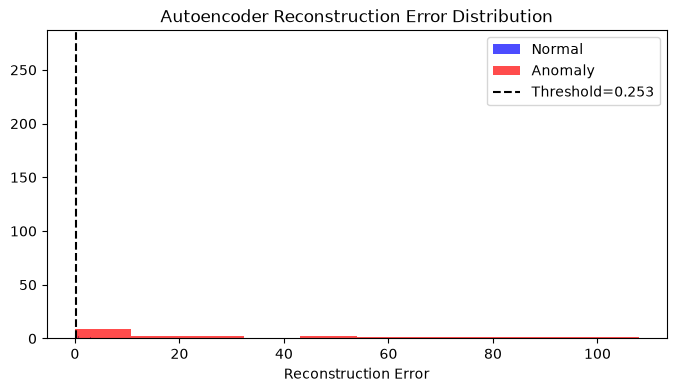


PyOD available models include:
  Linear: PCA, MCD, OCSVM
  Proximity: LOF, CBLOF, HBOS, KNN
  Ensemble: IForest, LODA, SOD
  Neural: AutoEncoder, VAE, DeepSVDD, ANOGAN


In [2]:
# Autoencoder for anomaly detection using PyTorch
try:
    import torch
    import torch.nn as nn
    
    class Autoencoder(nn.Module):
        def __init__(self, input_dim, latent_dim=2):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 16), nn.ReLU(),
                nn.Linear(16, 8), nn.ReLU(),
                nn.Linear(8, latent_dim)
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, 8), nn.ReLU(),
                nn.Linear(8, 16), nn.ReLU(),
                nn.Linear(16, input_dim)
            )
        def forward(self, x):
            return self.decoder(self.encoder(x))
    
    # Train only on normal data
    scaler = StandardScaler()
    X_normal_scaled = scaler.fit_transform(X_normal)
    X_all_scaled = scaler.transform(X)
    
    X_tensor = torch.FloatTensor(X_normal_scaled)
    model = Autoencoder(input_dim=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    for epoch in range(200):
        model.train()
        output = model(X_tensor)
        loss = criterion(output, X_tensor)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    
    # Anomaly score = reconstruction error
    model.eval()
    with torch.no_grad():
        X_all_tensor = torch.FloatTensor(X_all_scaled)
        recon = model(X_all_tensor)
        recon_error = ((X_all_tensor - recon)**2).mean(dim=1).numpy()
    
    # Threshold at 95th percentile of normal data errors
    with torch.no_grad():
        normal_recon = model(torch.FloatTensor(X_normal_scaled))
        normal_errors = ((torch.FloatTensor(X_normal_scaled) - normal_recon)**2).mean(dim=1).numpy()
    threshold = np.percentile(normal_errors, 95)
    y_ae = (recon_error > threshold).astype(int)
    y_ae_labels = np.where(y_ae, -1, 1)
    
    p = precision_score(y_true, y_ae_labels, pos_label=-1)
    r = recall_score(y_true, y_ae_labels, pos_label=-1)
    f = f1_score(y_true, y_ae_labels, pos_label=-1)
    print(f"{'Autoencoder':<20} {p:>10.4f} {r:>10.4f} {f:>10.4f}")
    
    plt.figure(figsize=(8, 4))
    plt.hist(recon_error[:n_normal], bins=50, alpha=0.7, label='Normal', color='blue')
    plt.hist(recon_error[n_normal:], bins=10, alpha=0.7, label='Anomaly', color='red')
    plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold={threshold:.3f}')
    plt.xlabel('Reconstruction Error'); plt.legend()
    plt.title('Autoencoder Reconstruction Error Distribution'); plt.show()
    
except ImportError:
    print("PyTorch not available. Install: pip install torch")

# PyOD overview
try:
    from pyod.models.iforest import IForest
    from pyod.models.vae import VAE
    from pyod.models.deep_svdd import DeepSVDD
    print("\nPyOD available models include:")
    print("  Linear: PCA, MCD, OCSVM")
    print("  Proximity: LOF, CBLOF, HBOS, KNN")
    print("  Ensemble: IForest, LODA, SOD")
    print("  Neural: AutoEncoder, VAE, DeepSVDD, ANOGAN")
except ImportError:
    print("Install PyOD: pip install pyod")

---

## 5. Time Series Anomaly Detection

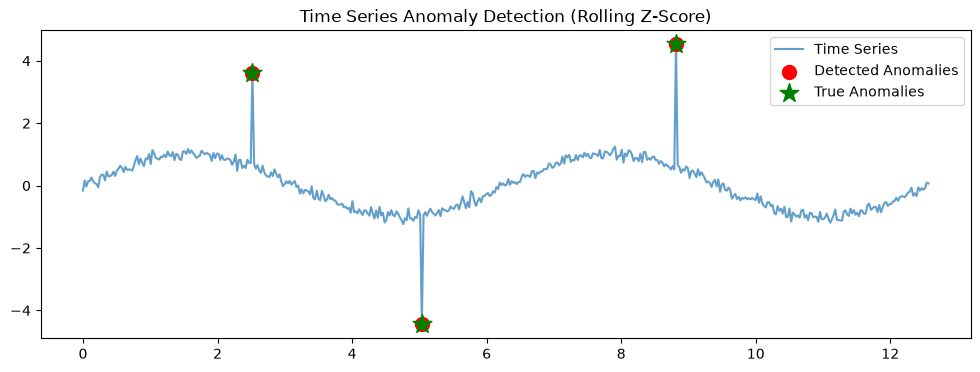

Detected 3 anomalies


In [3]:
# LSTM-based time series anomaly detection
import numpy as np

# Generate time series with anomalies
t = np.linspace(0, 4*np.pi, 500)
ts = np.sin(t) + 0.1*np.random.randn(500)
# Inject anomalies
anomaly_idx = [100, 200, 350]
ts[anomaly_idx] += np.array([3.0, -3.5, 4.0])

# Rolling statistics method
window = 20
roll_mean = pd.Series(ts).rolling(window).mean()
roll_std = pd.Series(ts).rolling(window).std()
z_scores = np.abs((ts - roll_mean) / (roll_std + 1e-8))
anomalies_detected = z_scores > 3.0

plt.figure(figsize=(12, 4))
plt.plot(t, ts, label='Time Series', alpha=0.7)
plt.scatter(t[anomalies_detected], ts[anomalies_detected], color='red', s=100, zorder=5, label='Detected Anomalies')
plt.scatter(t[anomaly_idx], ts[anomaly_idx], marker='*', color='green', s=200, zorder=6, label='True Anomalies')
plt.legend(); plt.title('Time Series Anomaly Detection (Rolling Z-Score)'); plt.show()
print(f"Detected {anomalies_detected.sum()} anomalies")

---

## Algorithm Selection Guide

| Scenario | Recommended Method |
|----------|--------------------|
| Low-dimensional, labeled normal data | Elliptic Envelope, One-Class SVM |
| High-dimensional, unlabeled | Isolation Forest |
| Local density anomalies | LOF, HBOS |
| Deep features / images | Autoencoder, VAE |
| Time series | LSTM-AE, Prophet, ADTK |
| Real-time / streaming | Half-Space Trees, xStream |

---

## Additional Learning Resources

### Papers
- **Isolation Forest**: [https://arxiv.org/abs/1811.02141](https://arxiv.org/abs/1811.02141)
- **LOF**: [https://dl.acm.org/doi/10.1145/335191.335388](https://dl.acm.org/doi/10.1145/335191.335388)
- **Deep SVDD**: [http://proceedings.mlr.press/v80/ruff18a.html](http://proceedings.mlr.press/v80/ruff18a.html)
- **Anomaly Detection Survey**: [https://arxiv.org/abs/2012.09119](https://arxiv.org/abs/2012.09119)

### Libraries
- **PyOD**: [https://pyod.readthedocs.io/](https://pyod.readthedocs.io/)
- **ADTK** (time series): [https://adtk.readthedocs.io/](https://adtk.readthedocs.io/)
- **Alibi-Detect**: [https://docs.seldon.io/projects/alibi-detect/](https://docs.seldon.io/projects/alibi-detect/)